Dataset Shape: (1000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,10001,15798485,Copley,565,France,Male,31,1,0.00,1,0,1,20443.08,0
1,10002,15588959,T'ang,569,France,Male,34,4,0.00,1,0,1,4045.90,0
2,10003,15624896,Ku,669,France,Female,20,7,0.00,2,1,0,128838.67,0
3,10004,15639629,McConnan,694,France,Male,39,4,173255.48,1,1,1,81293.10,0
4,10005,15638852,Ts'ui,504,Spain,Male,28,10,109291.36,1,1,1,187593.15,0



Missing values:
RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Churn column: Exited
ID columns: ['RowNumber', 'CustomerId']
Text columns: []

K-Means data shape: (1000, 725)


/var/folders/88/w4w1n8l12kd_z42_6mrnndmw0000gn/T/ipykernel_5026/1893584782.py:34: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:
/var/folders/88/w4w1n8l12kd_z42_6mrnndmw0000gn/T/ipykernel_5026/1893584782.py:71: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pand

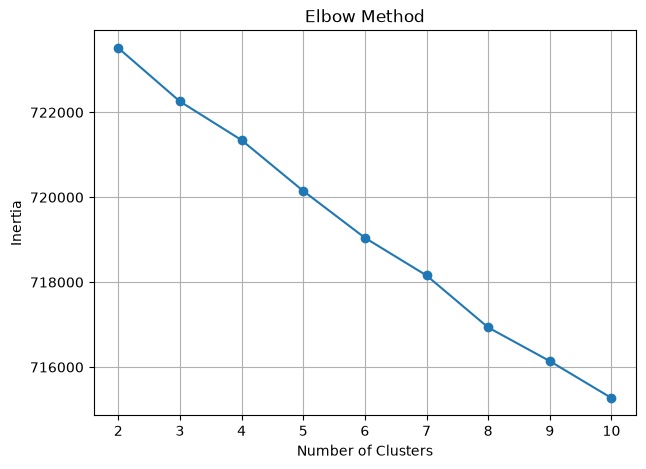

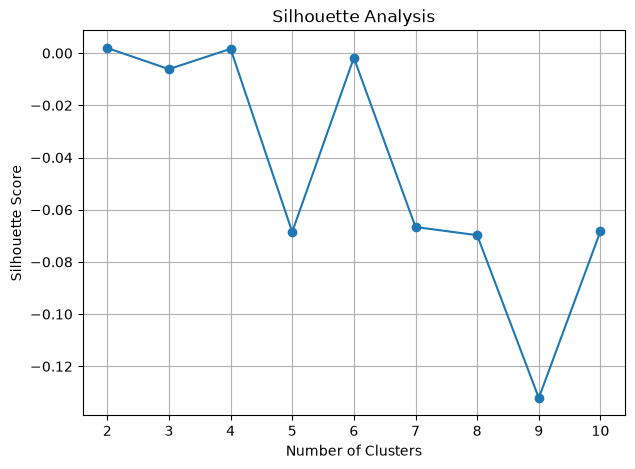

Best number of clusters: 2

Cluster counts:
Cluster
0    741
1    259
Name: count, dtype: int64


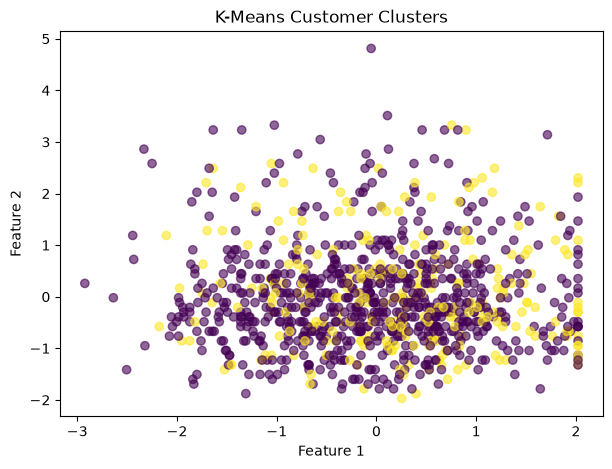


Cluster Profile:


,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
Cluster,,,,,,,,,,,
0,10507.19,15692712.58,644.49,38.93,4.91,66564.29,1.43,0.60,0.55,109205.47,0.24
1,10481.37,15692802.21,674.21,40.05,4.70,99752.47,1.80,0.91,0.47,79456.00,0.31



Churn by Cluster:


Cluster
0    24.16
1    31.27
Name: Churn_Numeric, dtype: float64


No suitable text column was found. NLP was skipped.

ANALYSIS COMPLETED
Output file:
Churn_KMeans_NLP_Results.csv


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Cluster,Churn_Numeric
0,10001,15798485,Copley,565,France,Male,31,1,0.00,1,0,1,20443.08,0,0,0
1,10002,15588959,T'ang,569,France,Male,34,4,0.00,1,0,1,4045.90,0,0,0
2,10003,15624896,Ku,669,France,Female,20,7,0.00,2,1,0,128838.67,0,0,0
3,10004,15639629,McConnan,694,France,Male,39,4,173255.48,1,1,1,81293.10,0,0,0
4,10005,15638852,Ts'ui,504,Spain,Male,28,10,109291.36,1,1,1,187593.15,0,0,0


In [1]:
# ============================================================
# CHURN MODELLING - K-MEANS + NLP
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

# ------------------------------------------------------------
# 1. LOAD DATA
# ------------------------------------------------------------

df = pd.read_csv("Churn Modelling Test Data.csv")

print("Dataset Shape:", df.shape)
display(df.head())

# ------------------------------------------------------------
# 2. CLEAN DATA
# ------------------------------------------------------------

df = df.drop_duplicates()

# Fill missing values
for col in df.select_dtypes(include=np.number).columns:
    df[col] = df[col].fillna(df[col].median())

for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].fillna("Unknown")

print("\nMissing values:")
print(df.isnull().sum())

# ------------------------------------------------------------
# 3. FIND CHURN COLUMN
# ------------------------------------------------------------

churn_col = None

for col in df.columns:
    if col.lower() in ["churn", "churned", "exited", "attrition"]:
        churn_col = col
        break

print("\nChurn column:", churn_col)

# ------------------------------------------------------------
# 4. REMOVE ID COLUMNS
# ------------------------------------------------------------

id_cols = []

for col in df.columns:
    if "id" in col.lower() or col.lower() in ["rownumber"]:
        id_cols.append(col)

print("ID columns:", id_cols)

# ------------------------------------------------------------
# 5. IDENTIFY TEXT COLUMNS
# ------------------------------------------------------------

text_cols = []

for col in df.select_dtypes(include="object").columns:

    if col == churn_col:
        continue

    if col in id_cols:
        continue

    if df[col].astype(str).str.len().mean() > 30:
        text_cols.append(col)

print("Text columns:", text_cols)

# ------------------------------------------------------------
# 6. PREPARE K-MEANS DATA
# ------------------------------------------------------------

X = df.drop(
    columns=id_cols + text_cols +
    ([churn_col] if churn_col else []),
    errors="ignore"
)

# One-hot encode categorical variables
X = pd.get_dummies(X, drop_first=True)

# Convert Boolean to integers
X = X.astype(float)

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nK-Means data shape:", X_scaled.shape)

# ------------------------------------------------------------
# 7. ELBOW METHOD
# ------------------------------------------------------------

inertia = []

for k in range(2, 11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)
    inertia.append(model.inertia_)

plt.figure(figsize=(7, 5))
plt.plot(range(2, 11), inertia, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.grid()
plt.show()

# ------------------------------------------------------------
# 8. SILHOUETTE SCORE
# ------------------------------------------------------------

scores = []

for k in range(2, 11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    scores.append(score)

plt.figure(figsize=(7, 5))
plt.plot(range(2, 11), scores, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")
plt.grid()
plt.show()

best_k = range(2, 11)[np.argmax(scores)]

print("Best number of clusters:", best_k)

# ------------------------------------------------------------
# 9. FINAL K-MEANS
# ------------------------------------------------------------

kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(X_scaled)

print("\nCluster counts:")
print(df["Cluster"].value_counts().sort_index())

# ------------------------------------------------------------
# 10. CLUSTER VISUALISATION
# ------------------------------------------------------------

plt.figure(figsize=(7, 5))

plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=df["Cluster"],
    alpha=0.6
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("K-Means Customer Clusters")
plt.show()

# ------------------------------------------------------------
# 11. CLUSTER PROFILE
# ------------------------------------------------------------

numeric_cols = df.select_dtypes(
    include=np.number
).columns.tolist()

numeric_cols = [
    col for col in numeric_cols
    if col != "Cluster"
]

print("\nCluster Profile:")

display(
    df.groupby("Cluster")[numeric_cols]
    .mean()
    .round(2)
)

# ------------------------------------------------------------
# 12. CHURN BY CLUSTER
# ------------------------------------------------------------

if churn_col:

    print("\nChurn by Cluster:")

    if df[churn_col].dtype == "object":

        churn_map = {
            "Yes": 1,
            "No": 0,
            "yes": 1,
            "no": 0,
            "True": 1,
            "False": 0
        }

        churn_numeric = df[churn_col].map(churn_map)

    else:

        churn_numeric = pd.to_numeric(
            df[churn_col],
            errors="coerce"
        )

    df["Churn_Numeric"] = churn_numeric

    churn_rate = (
        df.groupby("Cluster")["Churn_Numeric"]
        .mean() * 100
    )

    display(churn_rate.round(2))

# ------------------------------------------------------------
# 13. NLP - TF-IDF
# ------------------------------------------------------------

if len(text_cols) > 0:

    text_col = text_cols[0]

    print("\nNLP Text Column:", text_col)

    text = df[text_col].astype(str)

    tfidf = TfidfVectorizer(
        stop_words="english",
        max_features=1000
    )

    X_text = tfidf.fit_transform(text)

    print("TF-IDF Shape:", X_text.shape)

    # Reduce dimensions
    components = min(
        10,
        X_text.shape[1] - 1
    )

    svd = TruncatedSVD(
        n_components=components,
        random_state=42
    )

    X_nlp = svd.fit_transform(X_text)

    # NLP K-Means
    nlp_kmeans = KMeans(
        n_clusters=best_k,
        random_state=42,
        n_init=10
    )

    df["NLP_Cluster"] = nlp_kmeans.fit_predict(X_nlp)

    print("\nNLP Cluster Counts:")
    print(
        df["NLP_Cluster"]
        .value_counts()
        .sort_index()
    )

    # NLP visualisation
    plt.figure(figsize=(7, 5))

    plt.scatter(
        X_nlp[:, 0],
        X_nlp[:, 1],
        c=df["NLP_Cluster"],
        alpha=0.6
    )

    plt.xlabel("SVD Component 1")
    plt.ylabel("SVD Component 2")
    plt.title("NLP Customer Clusters")
    plt.show()

else:

    print(
        "\nNo suitable text column was found. "
        "NLP was skipped."
    )

# ------------------------------------------------------------
# 14. SAVE RESULTS
# ------------------------------------------------------------

df.to_csv(
    "Churn_KMeans_NLP_Results.csv",
    index=False
)

print("\n===================================")
print("ANALYSIS COMPLETED")
print("===================================")
print("Output file:")
print("Churn_KMeans_NLP_Results.csv")

display(df.head())